3장 분류와 회귀

In [ ]:
# 예제 3,1 MLP MNIST 분류

#셋업
import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.initializers import RandomNormal
from tensorflow.keras.datasets import mnist
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# 데이터셋 준비
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print(x_train.shape, y_train.shape)  # 학습 데이터 shape 확인
print(x_test.shape, y_test.shape)    # 테스트 데이터 shape 확인

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


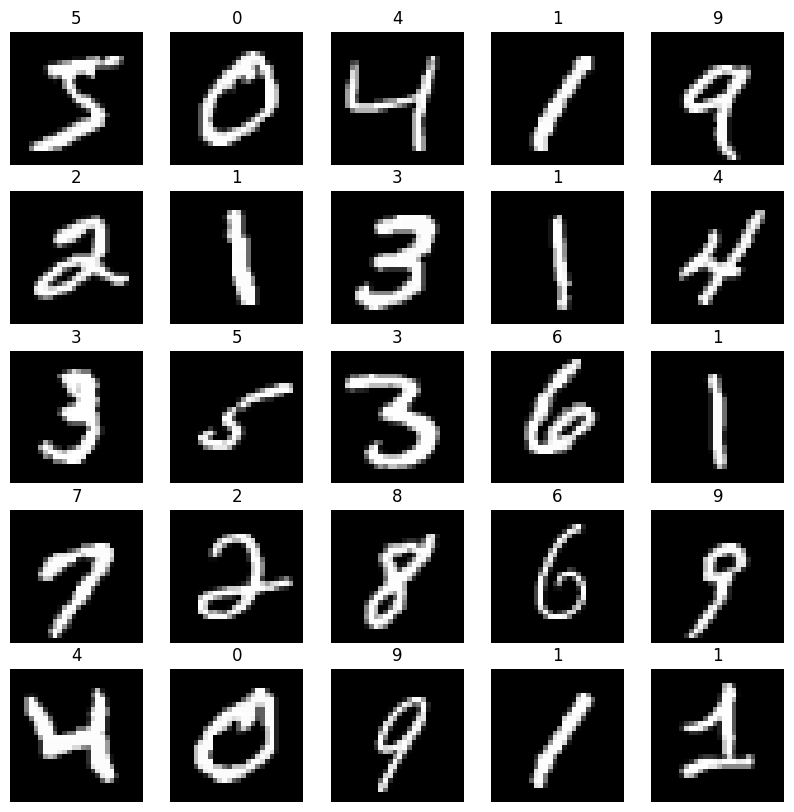

In [ ]:
# 학습 데이터 시각화
plt.figure(figsize=(10, 10))

for i in range(25):
    plt.subplot(5, 5, i+1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(y_train[i])   # 레이블
    plt.axis("off")

plt.show()

In [ ]:
# 데이터 정규화
x_train = x_train / 255   # 최소값 0, 최대값 255
x_test = x_test / 255

In [ ]:
# 학습 데이터/검증 데이터 분할
x_train, x_valid, y_train, y_valid = train_test_split(
    x_train, y_train,
    test_size=0.2,   # 분할 비율 0.2
    random_state=77)

print(x_train.shape, y_train.shape)   # 학습 데이터 shape 확인
print(x_valid.shape, y_valid.shape)   # 검증 데이터 shape 확인

(48000, 28, 28) (48000,)
(12000, 28, 28) (12000,)


In [ ]:
# 모델 생성
inputs = Input(shape=(28, 28))   # 입력 특징 28x28
x = Flatten()(inputs)   # 2차원 이미지를 벡터로 변환
x = Dense(128, kernel_initializer=RandomNormal(seed=77),   # 은닉층1 뉴런 128개
          activation="relu", name="hidden_layer1")(x)
x = Dense(64, kernel_initializer=RandomNormal(seed=77),    # 은닉층2 뉴런 64개
          activation="relu", name="hidden_layer2")(x)
outputs = Dense(10, kernel_initializer=RandomNormal(seed=77),   # 출력층 뉴런 10개
          activation="softmax", name="output_layer")(x)

model = Model(inputs, outputs)

In [ ]:
# 모델 컴파일
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])   # 성능 평가 지표로 정확도 사용

In [ ]:
# 모델 학습
history = model.fit(x_train, y_train, epochs=5,
                    validation_data=(x_valid, y_valid))   # 성능 검증용

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8336 - loss: 0.5902 - val_accuracy: 0.9514 - val_loss: 0.1626
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9597 - loss: 0.1371 - val_accuracy: 0.9597 - val_loss: 0.1268
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9719 - loss: 0.0905 - val_accuracy: 0.9635 - val_loss: 0.1149
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9813 - loss: 0.0639 - val_accuracy: 0.9716 - val_loss: 0.0908
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9856 - loss: 0.0475 - val_accuracy: 0.9698 - val_loss: 0.0995


In [ ]:
# 모델 평가
model.evaluate(x_test, y_test)   # 테스트 데이터로 성능 평가

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9674 - loss: 0.1045


[0.09140529483556747, 0.97079998254776]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
label: [7 2 1 0 4 1 4 9 5 9]


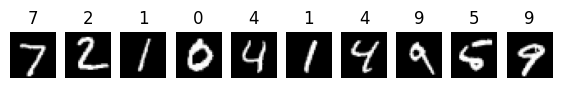

In [ ]:
# 모델 예측 결과
x = x_test[:10]
y_pred = np.argmax(model.predict(x), axis=1)

print(f"label: {y_test[:10]}")   # 테스트 데이터 레이블 확인

plt.figure(figsize=(7, 7))

for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(x_test[i], cmap="gray")
    plt.title(y_pred[i])
    plt.axis("off")

plt.show()

In [ ]:
# 예제 3.2 성능 평가(이진 분류)

# 셋업
import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.datasets import fashion_mnist
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# 데이터셋 준비
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

print(x_train.shape, y_train.shape)   # 학습 데이터 shape 확인
print(x_test.shape, y_test.shape)   # 테스트 데이터 shape 확인

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


In [ ]:
# 레이블 5(sandal)/레이블 7(sneakers) 샘플 추출
index1 = (y_train == 5) | (y_train == 7)
x_train = x_train[index1]   # 학습 데이터

index2 = (y_test == 5) | (y_test == 7)
x_test = x_test[index2]   # 테스트 데아터

# 레이블 재지정
y_train = (y_train[index1] == 7).astype(int)   # 학습 데이터 레이블
y_test = (y_test[index2] == 7).astype(int)   # 테스트 데이터 레이블

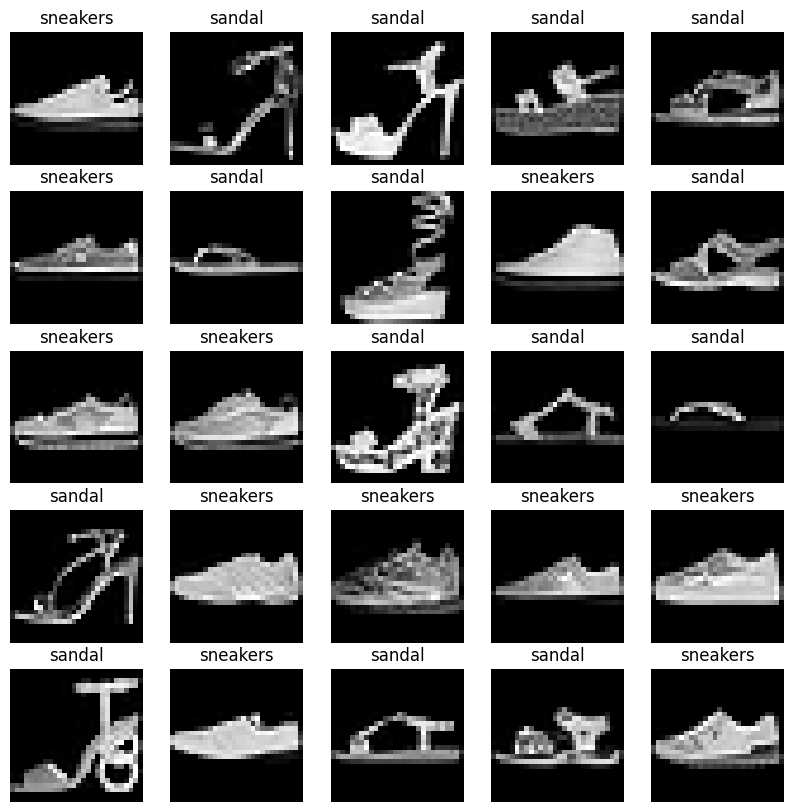

In [ ]:
# 학습 데이터 시각화(클래스명 표시)
class_names = ["sandal", "sneakers"]

plt.figure(figsize=(10, 10))

for i in range(25):
    plt.subplot(5, 5, i+1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(class_names[y_train[i].item()])   # 레이블(클래스명) 표시
    plt.axis("off")

plt.show()

In [ ]:
# 데이터 정규화
x_train = x_train / 255
x_test = x_test / 255

In [ ]:
# 모델 생성
inputs = Input(shape=(28, 28))
x = Flatten()(inputs)
x = Dense(16, activation="relu")(x)   # 은닉층 뉴런 16개
outputs = Dense(1, activation="sigmoid")(x)   # 출력층 뉴런 1개

model = Model(inputs, outputs)

In [ ]:
# 모델 컴파일
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

In [ ]:
# 모델 학습
history = model.fit(x_train, y_train, epochs=5, verbose=0,
                    validation_split=0.2)   # 분할 비율 0.2

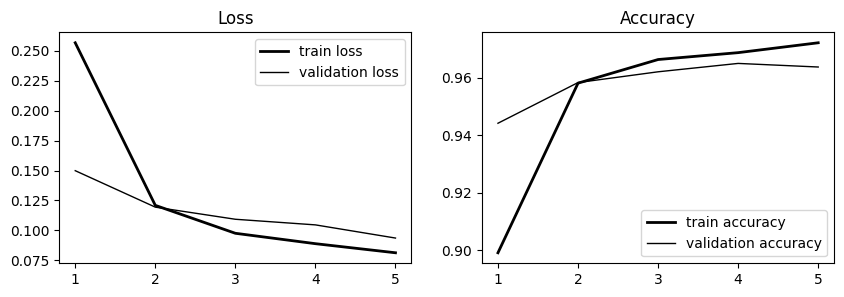

In [ ]:
# 학습 결과 시각화
plt.figure(figsize=(10, 3))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(history.history["loss"]) + 1),
         history.history["loss"], label="train loss",
         color="black", linewidth=2)
plt.plot(range(1, len(history.history["val_loss"]) + 1),
         history.history["val_loss"], label="validation loss",
         color="black", linewidth=1)
plt.title("Loss")
plt.legend(loc="best")

plt.subplot(1, 2, 2)
plt.plot(range(1, len(history.history["accuracy"]) + 1),
         history.history["accuracy"], label="train accuracy",
         color="black", linewidth=2)
plt.plot(range(1, len(history.history["val_accuracy"]) + 1),
         history.history["val_accuracy"], label="validation accuracy",
         color="black", linewidth=1)
plt.title("Accuracy")
plt.legend(loc="best")

plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
y_test: [0 1 0 1 0]
y_pred: [0 1 0 1 1]


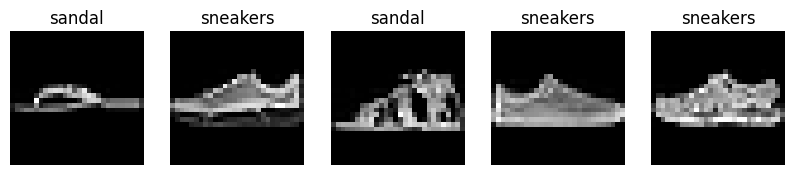

In [ ]:
# 모델 예측(임계치에 따라 0/1 판단)
threshold = 0.5   # 임계치 0.5
y_pred = (model.predict(x_test) >= threshold).astype(int)

print(f"y_test: {y_test[:5]}")   # 테스트 데이터 레이블 확인
print(f"y_pred: {y_pred[:5].reshape(-1)}")   # 예측한 레이블 확인

# 예측 결과 시각화
plt.figure(figsize=(10, 10))

for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(x_test[i], cmap="gray")
    plt.title(class_names[y_pred[i].item()])   # 예측한 클래스명 표시
    plt.axis("off")
plt.show()

accuracy: 0.94
precision: 0.90


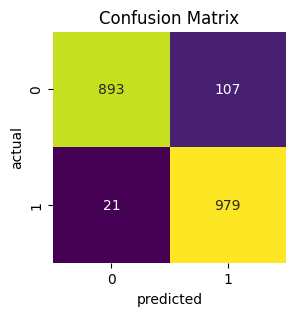

In [ ]:
#성능 평가 지표 출력
print(f"accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(f"precision: {precision_score(y_test, y_pred):.2f}")

# 혼동 행렬
plt.figure(figsize=(3, 3))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("predicted")
plt.ylabel("actual")

plt.show()

In [ ]:
# 예제 3.3  MLP 보스턴 주택 가격 예측

# 셋업
import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.datasets import boston_housing
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# 데이터셋 준비
(x_train, y_train), (x_test, y_test) = boston_housing.load_data()

print(x_train.shape, y_train.shape)   # 학습 데이터 shape
print(x_test.shape, y_test.shape)     # 테스트 데이터 shape

(404, 13) (404,)
(102, 13) (102,)


In [ ]:
# 데이터 정규화
mean = np.mean(x_train, axis=0)
std = np.std(x_train, axis=0)

x_train = (x_train - mean) / std
x_test = (x_test - mean) / std

In [ ]:
# 학습 데이터/검증 데이터 분할
x_train, x_valid, y_train, y_valid = train_test_split(
    x_train, y_train,
    test_size=0.2,   # 분할 비율 0.2
    random_state=77)

In [ ]:
# 모델 생성
inputs = Input(shape=(13, ))    # 입력 특징 13개
x = Dense(64, activation="relu")(inputs)  # 은닉층1 뉴런 64개
x = Dense(32, activation="relu")(x)  # 은닉층2 뉴런 32개
outputs = Dense(1)(x)   # 출력층 뉴런 1개(활성화 함수 사용하지 않음)

model = Model(inputs, outputs)

In [ ]:
# 모델 컴파일
model.compile(optimizer="adam", loss="mse", metrics=["mae"])

In [ ]:
# 모델 학습
history = model.fit(x_train, y_train,
                    epochs=200, verbose=0,
                    validation_data=(x_valid, y_valid))

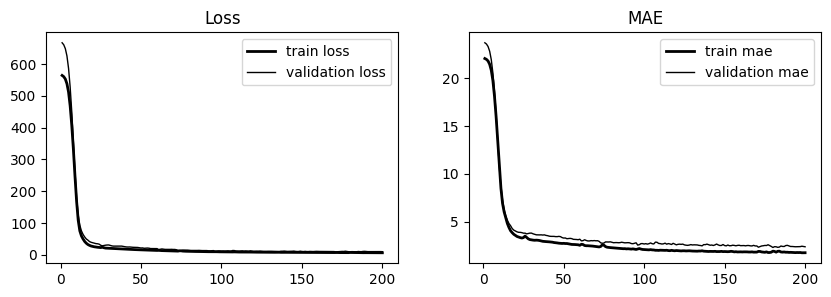

In [ ]:
# 학습 결과 시각화
plt.figure(figsize=(10, 3))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(history.history["loss"]) + 1),
         history.history["loss"], label="train loss",
         color="black", linewidth=2)
plt.plot(range(1, len(history.history["val_loss"]) + 1),
         history.history["val_loss"], label="validation loss",
         color="black", linewidth=1)
plt.title("Loss")
plt.legend(loc="best")

plt.subplot(1, 2, 2)
plt.plot(range(1, len(history.history["mae"]) + 1),
         history.history["mae"], label="train mae",
         color="black", linewidth=2)
plt.plot(range(1, len(history.history["val_mae"]) + 1),
         history.history["val_mae"], label="validation mae",
         color="black", linewidth=1)
plt.title("MAE")
plt.legend(loc="best")

plt.show()

In [ ]:
# 모델 평가
model.evaluate(x_test, y_test)   # 테스트 데이터로 성능 평가

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 13.9401 - mae: 2.6071


[17.48990821838379, 2.777632236480713]

In [ ]:
# 모델 예측
y_pred = model.predict(x_test[:5])

print(y_test[:5], "\n")
print(y_pred.reshape(-1).round(2))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step
[ 7.2 18.8 19.  27.  22.2] 

[ 8.33 18.21 21.58 35.25 24.4 ]
